In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../../")

# Downloading data

In [3]:
import os
from typing import List
from datetime import datetime

from dotenv import load_dotenv
import pandas as pd

from fractal.loaders.thegraph.uniswap_v3 import EthereumUniswapV3Loader
from fractal.loaders.base_loader import LoaderType
from fractal.core.base import Observation
from examples.tau_strategy.tau_strategy import build_observations
from fractal.loaders.thegraph.uniswap_v3.uniswap_v3_pool import UniswapV3EthereumPoolHourDataLoader, UniswapV3EthereumPoolMinuteDataLoader
from fractal.loaders.binance import BinanceHourPriceLoader, BinanceMinutePriceLoader
from fractal.loaders.structs import PoolHistory, PriceHistory
from fractal.core.entities.uniswap_v3_lp import UniswapV3LPGlobalState



def get_observations(
        pool_data: PoolHistory, price_data: PriceHistory,
        start_time: datetime = None, end_time: datetime = None
    ) -> List[Observation]:
    """
    Get observations from the pool and price data for the TauResetStrategy.

    Returns:
        List[Observation]: The observation list for TauResetStrategy.
    """
    price_data['centralized_price'] = price_data['price'].astype(float)
    price_data.drop(columns=['price'], inplace=True)
    observations_df: pd.DataFrame = pool_data.join(price_data)
    observations_df = observations_df.dropna()

    observations_df = observations_df[observations_df.tvl > 0]
    observations_df = observations_df.sort_index()
    print(f"observations_df.columns {observations_df.columns}")
    return [
        Observation(
            timestamp=timestamp,
            states={
                'UNISWAP_V3': UniswapV3LPGlobalState(
                    price=price, 
                    tvl=tvls, 
                    volume=volume, 
                    fees=fees, 
                    liquidity=liquidity,
                    centralized_price=centralized_price,
                    open_price=open,
                    close_price=close,
                    high_price=high,
                    low_price=low,
                ),
            }
        ) for timestamp, (tvls, volume, fees, liquidity, price, open, high, low, close, centralized_price) in observations_df.iterrows()
    ]


def build_observations(
        ticker: str, pool_address: str, api_key: str,
        start_time: datetime = None, end_time: datetime = None, fidelity: str = 'hour',
    ) -> List[Observation]:
    """
    Build observations for the TauResetStrategy from the given start and end time.
    """
    if fidelity == 'hour':
        pool_data: PoolHistory = UniswapV3EthereumPoolHourDataLoader(
            api_key, pool_address, loader_type=LoaderType.CSV, start_time=start_time, end_time=end_time).read(with_run=True)
        binance_prices: PriceHistory = BinanceHourPriceLoader(ticker, loader_type=LoaderType.CSV).read(with_run=True)
        print(f"pool_data.columns {pool_data.columns}")
    elif fidelity == 'minute':
        pool_data: PoolHistory = UniswapV3EthereumPoolMinuteDataLoader(
            api_key, pool_address, loader_type=LoaderType.CSV).read(with_run=True)
        binance_prices: PriceHistory = BinanceMinutePriceLoader(ticker, loader_type=LoaderType.CSV,
                                                                start_time=start_time, end_time=end_time).read(with_run=True)

        
    return get_observations(pool_data, binance_prices, start_time, end_time)



load_dotenv()
ticker: str = 'ETHUSDT'
pool_address: str = '0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8'
THE_GRAPH_API_KEY = os.getenv('THE_GRAPH_API_KEY')

# Load data
token0_decimals, token1_decimals = EthereumUniswapV3Loader(
    THE_GRAPH_API_KEY, loader_type=LoaderType.CSV).get_pool_decimals(pool_address)

# Build observations
observations: List[Observation] = build_observations(
    ticker=ticker, 
    pool_address=pool_address,
    api_key=THE_GRAPH_API_KEY,
    start_time=datetime(2024, 3, 20), # min timestamp with fees > 0
    end_time=datetime(2025, 4, 25),
    fidelity='hour'
)
observation0 = observations[0]
observation0


pool_data.columns Index(['tvl', 'volume', 'fees', 'liquidity', 'price', 'open', 'high', 'low',
       'close'],
      dtype='object')
observations_df.columns Index(['tvl', 'volume', 'fees', 'liquidity', 'price', 'open', 'high', 'low',
       'close', 'centralized_price'],
      dtype='object')


Observation(timestamp=2024-03-19 21:00:00+00:00, states={'UNISWAP_V3': UniswapV3LPGlobalState(tvl=317256101.3949567, volume=536895.7831671502, fees=1610.6873495014509, liquidity=1.4513494727019018e+18, price=3285.5963803529758, centralized_price=3293.01, open_price=3279.179804687722, close_price=3285.5963803529758, high_price=3287.09640069871, low_price=3264.396181006303)})

In [4]:
token0_decimals, token1_decimals

(6.0, 18.0)

# Split data into train and test

In [5]:
from typing import Tuple


def split_observations_by_time(
    observations: List[Observation],
    train_ratio: float = 0.8,
    test_ratio: float = 0.2
) -> Tuple[List[Observation], List[Observation]]:
    """
    Split observations into train and test sets by timestamp.
    The split is done chronologically to maintain the time sequence.
    
    Args:
        observations: List of observations to split
        train_ratio: Ratio of observations to use for training (default: 0.7)
        test_ratio: Ratio of observations to use for testing (default: 0.3)
        
    Returns:
        Tuple of (train_observations, test_observations)
        
    Raises:
        ValueError: If train_ratio + test_ratio != 1.0
    """
    if not (0 < train_ratio < 1 and 0 < test_ratio < 1):
        raise ValueError("train_ratio and test_ratio must be between 0 and 1")
    
    if abs(train_ratio + test_ratio - 1.0) > 1e-6:
        raise ValueError("train_ratio + test_ratio must equal 1.0")
    
    # Sort observations by timestamp to ensure chronological order
    sorted_observations = sorted(observations, key=lambda x: x.timestamp)
    
    # Calculate split indices
    total_obs = len(sorted_observations)
    train_size = int(total_obs * train_ratio)
    
    # Split observations
    train_observations = sorted_observations[:train_size]
    test_observations = sorted_observations[train_size:]
    
    return train_observations, test_observations
    


In [6]:
train_observations, test_observations = split_observations_by_time(observations)

In [7]:
len(train_observations)

7948

In [8]:
print(min([obs.timestamp for obs in train_observations]))
print(min([obs.timestamp for obs in test_observations]))


2024-03-19 21:00:00+00:00
2025-02-18 19:00:00+00:00


# Training model

In [9]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=<Your access key>
%env CLEARML_API_SECRET_KEY=<Your secret key>

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=75J86NR0W672MX1IMXSAW3Z74PKA4C
env: CLEARML_API_SECRET_KEY=1tnDAKa-O0bMYJPx89g5XuubsM3WoJr0vjH9z5DdLj4bwYhaF7uyx2To47WzLQWoSS4


In [75]:
from fractal.strategies.rl_strategy import RLStrategy, RLStrategyParams
from stable_baselines3 import PPO

from clearml import Task

task = Task.init(
    project_name='AI_IN_BLOCKCHAIN', 
    task_name='UNISWAP_V3_LP_RL_STRATEGY',
    auto_resource_monitoring=False,
)

params = RLStrategyParams(
    INITIAL_BALANCE=10**4,
    MODEL_CLASS=PPO,
    # MODEL_CONFIG=PPOConfig()
)
print(params)
RLStrategy.token0_decimals = token0_decimals
RLStrategy.token1_decimals = token1_decimals
RLStrategy.tick_spacing = 60

strategy = RLStrategy(params, debug=True)

print("Training...")
result = strategy.train(train_observations, total_timesteps=int(6 * 1e4))

task.close()

ClearML Task: overwriting (reusing) task id=ed2294fc25cd472ca0dab0527a4abf87
ClearML results page: https://app.clear.ml/projects/ec648bc989a74c32b4a58e89c2a5e095/experiments/ed2294fc25cd472ca0dab0527a4abf87/output/log
RLStrategyParams(INITIAL_BALANCE=10000, MODEL_CLASS=<class 'stable_baselines3.ppo.ppo.PPO'>, MODEL_CONFIG=PPOConfig(learning_rate=0.0003, batch_size=64, seed=44, net_arch=[128, 128], n_steps=2048, n_epochs=200, gamma=0.95, gae_lambda=0.95, clip_range=0.2))
Training...


# Testing model

In [77]:
strategy._remove_entity("UNISWAP_V3")
strategy.set_up()
strategy.deposited_initial_funds = False
result = strategy.run(test_observations)

In [78]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

from fractal.core.base.strategy.result import StrategyResult
from typing import Optional
    

def visualize_results(strategy_result: StrategyResult, save_path: Optional[str] = None):
    """
    Visualize the strategy results including price movement and liquidity boundaries.
    
    Args:
        strategy_result: The result from running the strategy
        save_path: Optional path to save the plot
    """
    # Convert timestamps to datetime objects
    timestamps = np.array([pd.to_datetime(ts) for ts in strategy_result.timestamps])
    
    # Extract data
    prices = np.array([state['UNISWAP_V3'].price for state in strategy_result.global_states])
    lower_bounds = np.array([state['UNISWAP_V3'].price_lower for state in strategy_result.internal_states])
    upper_bounds = np.array([state['UNISWAP_V3'].price_upper for state in strategy_result.internal_states])
    
    # Create figure with subplots
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
    
    # Plot price and boundaries
    ax.plot(timestamps, prices, label='Price', color='blue', linewidth=1)
    ax.scatter(timestamps[lower_bounds > 0], lower_bounds[lower_bounds > 0], label='Lower Bound', color='red', marker='o', s=5)
    ax.scatter(timestamps[upper_bounds > 0], upper_bounds[upper_bounds > 0], label='Upper Bound', color='green', marker='o', s=5)

    plt.vlines(x=timestamps[lower_bounds > 0], ymin=lower_bounds[lower_bounds > 0], ymax=upper_bounds[lower_bounds > 0], colors='green', lw=0.1)

    # Format price plot
    ax.set_ylabel('Price')
    ax.set_title('Price Movement and Liquidity Boundaries')
    ax.legend()
    ax.grid(True)
    
    plt.xticks(rotation=45)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save or show plot
    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()
    
    plt.close()

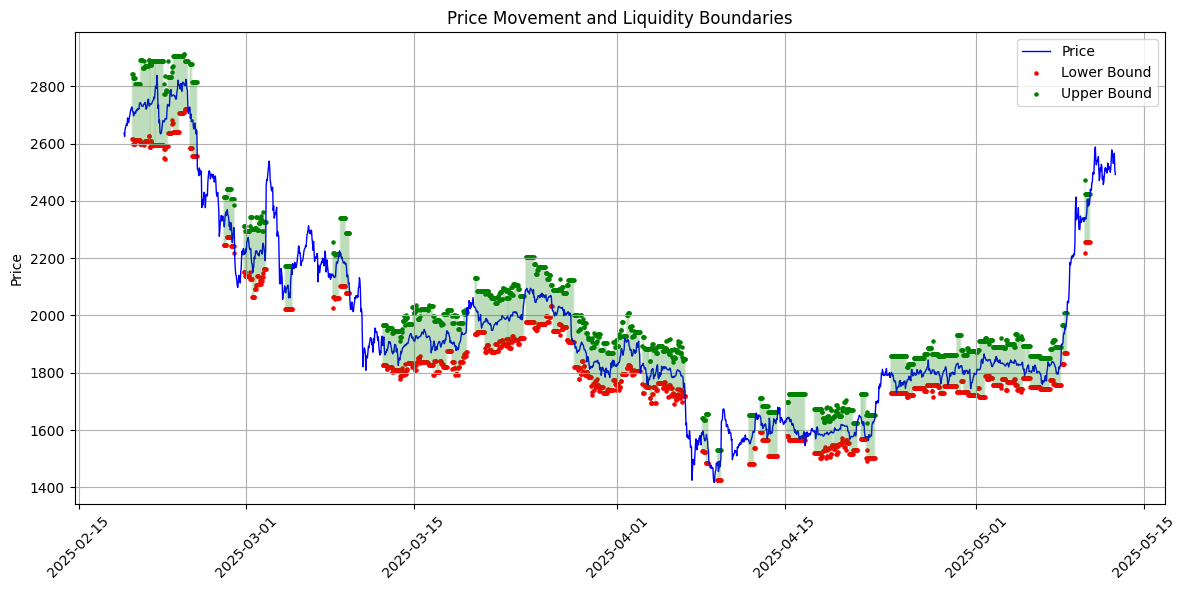

In [79]:
visualize_results(result)

In [80]:
result.get_default_metrics()

StrategyMetrics(accumulated_return=np.float64(-0.46053283019210034), apy=np.float64(-2.029309654166398), sharpe=np.float64(-7.9729452358130715), max_drawdown=np.float64(-0.4969852517728187))

In [81]:
df = result.to_dataframe()
df

,timestamp,UNISWAP_V3_token0_amount_hold,UNISWAP_V3_token1_amount_hold,UNISWAP_V3_token0_amount_position,UNISWAP_V3_token1_amount_position,UNISWAP_V3_token0_amount_position_init,UNISWAP_V3_token1_amount_position_init,UNISWAP_V3_price_init,UNISWAP_V3_price_lower,UNISWAP_V3_price_upper,...,UNISWAP_V3_volume,UNISWAP_V3_fees,UNISWAP_V3_price,UNISWAP_V3_centralized_price,UNISWAP_V3_open_price,UNISWAP_V3_close_price,UNISWAP_V3_high_price,UNISWAP_V3_low_price,UNISWAP_V3_balance,net_balance
0,2025-02-18 19:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.032962e+06,3098.885585,2636.766896,2628.80,2631.044011,2636.766896,2636.954116,2620.770538,10000.000000,10000.000000
1,2025-02-18 20:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.627073e+05,2588.121818,2625.319178,2630.06,2634.985261,2625.319178,2634.985261,2624.779015,10000.000000,10000.000000
2,2025-02-18 21:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.212740e+05,2763.821940,2649.247274,2651.38,2626.490237,2649.247274,2649.247274,2626.490237,10000.000000,10000.000000
3,2025-02-18 22:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.285983e+05,985.794934,2657.833042,2654.60,2649.247274,2657.833042,2657.833042,2649.247274,10000.000000,10000.000000
4,2025-02-18 23:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.914218e+05,574.265415,2662.841550,2670.57,2657.937462,2662.841550,2662.841550,2657.937462,10000.000000,10000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1982,2025-05-12 11:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.696684e+05,2909.005179,2531.074190,2529.34,2556.962664,2531.074190,2558.790326,2531.074190,5394.671698,5394.671698
1983,2025-05-12 12:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.768848e+05,2030.654411,2552.844013,2548.49,2531.074190,2552.844013,2552.844013,2531.074190,5394.671698,5394.671698
1984,2025-05-12 13:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.462038e+06,4386.113687,2566.253411,2556.99,2552.844013,2566.253411,2568.161001,2552.844013,5394.671698,5394.671698
1985,2025-05-12 14:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.346048e+06,10038.143875,2511.777415,2504.93,2565.216338,2511.777415,2565.216338,2500.855547,5394.671698,5394.671698


In [82]:
df["UNISWAP_V3_earned_fees"]

0          0.000000
1          0.000000
2          0.000000
3          0.000000
4          0.000000
           ...     
1982    2723.535029
1983    2723.535029
1984    2723.535029
1985    2723.535029
1986    2723.535029
Name: UNISWAP_V3_earned_fees, Length: 1987, dtype: float64

# Metrics Calculation

In [83]:
def calculate_total_return_and_apy(df):
    """Calculate total return and APY from strategy results"""
    initial_balance = df['net_balance'].iloc[1]
    final_balance = df['net_balance'].iloc[-1]
    total_return = (final_balance / initial_balance - 1) if initial_balance != 0 else 0
    
    # Calculate days between first and last timestamp
    days = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).days
    apy = ((1 + total_return) ** (365/days) - 1) if days > 0 else 0
    
    return total_return, apy

def calculate_fees_to_tvl_ratio(df):
    """Calculate ratio of earned fees to locked capital (TVL)"""
    position_df = df[(df["UNISWAP_V3_price_upper"] > 0) & (df["UNISWAP_V3_price_lower"] > 0)]
    
    position_df = (
        position_df
        .groupby(["UNISWAP_V3_price_upper", "UNISWAP_V3_price_lower"])
        .nth(-1)
    )
    # Calculate impermanent loss for each position
    ratio_values = []
    for _, row in position_df.iterrows():
        current_fees = row['UNISWAP_V3_earned_fees']
        initial_balance = row['net_balance']
        
        if initial_balance > 0:
            # Calculate price ratio
            price_ratio = current_fees / initial_balance
            
            ratio_values.append(abs(price_ratio))
    
    return np.mean(ratio_values) if ratio_values else 0

def calculate_impermanent_loss_mean(df):
    """Calculate mean impermanent loss"""
    # Filter rows where position exists
    position_df = df[(df["UNISWAP_V3_price_upper"] > 0) & (df["UNISWAP_V3_price_lower"] > 0)]

    position_df = (
        position_df
        .groupby(["UNISWAP_V3_price_upper", "UNISWAP_V3_price_lower"])
        .nth(-1)
    )
    
    # Calculate impermanent loss for each position
    il_values = []
    for _, row in position_df.iterrows():
        current_price = row['UNISWAP_V3_price']
        initial_price = row['UNISWAP_V3_price_init']
        
        if initial_price > 0:
            # Calculate price ratio
            price_ratio = current_price / initial_price
            
            # Calculate impermanent loss using the formula: IL = 2√(P2/P1)/(1 + P2/P1) - 1
            il = 2 * np.sqrt(price_ratio) / (1 + price_ratio) - 1
            il_values.append(abs(il))
    
    return np.mean(il_values) if il_values else 0

def calculate_returns_volatility(df):
    """Calculate returns volatility"""
    # Calculate daily returns
    returns = df['net_balance'].pct_change().dropna()
    # Calculate annualized volatility
    annual_volatility = returns.std() * np.sqrt(365)
    return annual_volatility

def calculate_max_drawdown(df):
    """Calculate maximum drawdown"""
    # Calculate cumulative maximum of net balance
    rolling_max = df['net_balance'].expanding().max()
    # Calculate drawdown
    drawdown = df['net_balance'] / rolling_max - 1
    # Get maximum drawdown
    max_drawdown = drawdown.min()
    return max_drawdown

def calculate_liquidity_interval_width(df):
    """Calculate mean width of liquidity interval"""
    # Calculate width between upper and lower bounds
    upper_bounds = np.floor(df[df['UNISWAP_V3_price_upper'] > 0]['UNISWAP_V3_price_upper'] / 60) * 60
    lower_bounds = np.floor(df[df['UNISWAP_V3_price_lower'] > 0]['UNISWAP_V3_price_lower'] / 60) * 60
    prices = np.floor(df[df['UNISWAP_V3_price_upper'] > 0]['UNISWAP_V3_price'] / 60) * 60
    width = (upper_bounds - lower_bounds) / 60
    return width.mean(), width.min(), width.max()

def calculate_rebalances_metrics(df):
    """Calculate rebalancing metrics"""
    total_rebalances = len(df["UNISWAP_V3_price_upper"].unique())
    days = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).days
    avg_rebalances_per_day = total_rebalances / days if days > 0 else 0
    return total_rebalances, avg_rebalances_per_day

# Calculate all metrics
total_return, apy = calculate_total_return_and_apy(df)
fees_balance_ratio = calculate_fees_to_tvl_ratio(df)
il_mean = calculate_impermanent_loss_mean(df)
volatility = calculate_returns_volatility(df)
max_drawdown = calculate_max_drawdown(df)
width_mean, width_min, width_max = calculate_liquidity_interval_width(df)
total_rebalances, avg_rebalances_per_day = calculate_rebalances_metrics(df)

print(f"Total Return: {total_return:.2%}")
print(f"APY: {apy:.2%}")
print(f"Fees/Balance Ratio: {fees_balance_ratio:.4%}")
print(f"Mean Impermanent Loss: {il_mean:.4%}")
print(f"Maximum Drawdown: {max_drawdown:.2%}")
print(f"Liquidity Interval Width - Mean: {width_mean:.4f}, Min: {width_min:.4f}, Max: {width_max:.4f}")
print(f"Total Rebalances: {total_rebalances}")
print(f"Average Rebalances per Day: {avg_rebalances_per_day:.2f}")


Total Return: -46.05%
APY: -93.59%
Fees/Balance Ratio: 24.5024%
Mean Impermanent Loss: 0.0014%
Maximum Drawdown: -49.70%
Liquidity Interval Width - Mean: 2.6133, Min: 1.0000, Max: 5.0000
Total Rebalances: 326
Average Rebalances per Day: 3.98
